In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/healthcare-dataset-stroke-data.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
df.shape

(5110, 12)

In [ ]:
df.isnull().sum().sort_values(ascending = False)

,0
bmi,201
id,0
age,0
gender,0
hypertension,0
heart_disease,0
work_type,0
ever_married,0
Residence_type,0
avg_glucose_level,0


In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df.drop(['id'],axis=1,inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True,inplace=True)
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


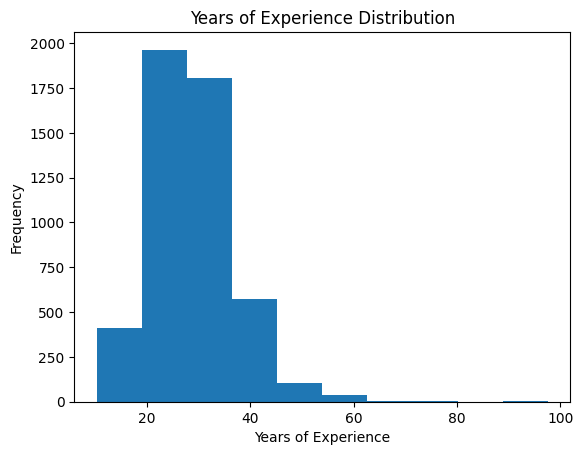

In [ ]:
plt.hist(df['bmi'])
plt.title('Years of Experience Distribution')
plt.xlabel('Years of Experience')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df['bmi'].skew()

np.float64(1.0553402052962912)

In [ ]:
from sklearn.impute import SimpleImputer

imputer=SimpleImputer(missing_values=np.nan,strategy='median')

imputer.fit(df[['bmi']])
df['bmi']=imputer.transform(df[['bmi']])

In [ ]:
df['bmi'].isnull().sum()

np.int64(0)

In [ ]:
df.select_dtypes(include=['object']).columns
for col in df.select_dtypes(include=['object']).columns:
    print(f'number of column {col} is : ',df[col].nunique())
    print(f'number of column {col} is : ',df[col].unique())

number of column gender is :  3
number of column gender is :  ['Male' 'Female' 'Other']
number of column ever_married is :  2
number of column ever_married is :  ['Yes' 'No']
number of column work_type is :  5
number of column work_type is :  ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
number of column Residence_type is :  2
number of column Residence_type is :  ['Urban' 'Rural']
number of column smoking_status is :  4
number of column smoking_status is :  ['formerly smoked' 'never smoked' 'smokes' 'Unknown']


In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore')

ohe_encoded = ohe.fit_transform(df[['gender', 'work_type']]).toarray()
ohe_df = pd.DataFrame(
    ohe_encoded,
    columns=ohe.get_feature_names_out(['gender', 'work_type']),
    index=df.index
)

df = pd.concat([df, ohe_df], axis=1)
df.drop(['gender', 'work_type'],axis =1 ,inplace =True)
df.head()

,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,gender_Female,gender_Male,gender_Other,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children
0,67.0,0,1,Yes,Urban,228.69,36.6,formerly smoked,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,61.0,0,0,Yes,Rural,202.21,28.1,never smoked,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,80.0,0,1,Yes,Rural,105.92,32.5,never smoked,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,49.0,0,0,Yes,Urban,171.23,34.4,smokes,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,79.0,1,0,Yes,Rural,174.12,24.0,never smoked,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['ever_married'] = le.fit_transform(df['ever_married'])
df['Residence_type'] = le.fit_transform(df['Residence_type'])
df.head()

,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,gender_Female,gender_Male,gender_Other,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children
0,67.0,0,1,1,1,228.69,36.6,formerly smoked,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,61.0,0,0,1,0,202.21,28.1,never smoked,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,80.0,0,1,1,0,105.92,32.5,never smoked,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,49.0,0,0,1,1,171.23,34.4,smokes,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,79.0,1,0,1,0,174.12,24.0,never smoked,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
df["smoking_status"] = enc.fit_transform(df[["smoking_status"]])
df.head()

,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,gender_Female,gender_Male,gender_Other,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children
0,67.0,0,1,1,1,228.69,36.6,1.0,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,61.0,0,0,1,0,202.21,28.1,2.0,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,80.0,0,1,1,0,105.92,32.5,2.0,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,49.0,0,0,1,1,171.23,34.4,3.0,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,79.0,1,0,1,0,174.12,24.0,2.0,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


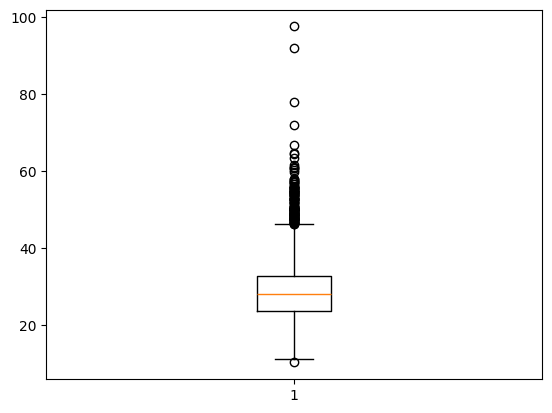

In [ ]:
plt.boxplot(df['bmi'])
plt.show()

In [ ]:
def remove_outliers_iqr(data, column_name="value"):

    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column_name] >= lower) & (df[column_name] <= upper)]
cleaned_df = remove_outliers_iqr(df, column_name="bmi")

print(df.shape,cleaned_df.shape)

(5110, 17) (4984, 17)


In [ ]:
X=df.drop(['stroke'],axis=1)
y=df['stroke']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                   test_size= 0.20, random_state=100, stratify=None)

print("X_train = ",X_train.shape ," y_train = ", y_train.shape)
print("X_test  = ",X_test.shape ," y_test  = ", y_test.shape)

X_train =  (4088, 16)  y_train =  (4088,)
X_test  =  (1022, 16)  y_test  =  (1022,)


In [ ]:
from sklearn.preprocessing import StandardScaler
my_scaler = StandardScaler()
X_train[['bmi']] = my_scaler.fit_transform(X_train[['bmi']])
X_test[['bmi']] = my_scaler.transform(X_test[['bmi']])

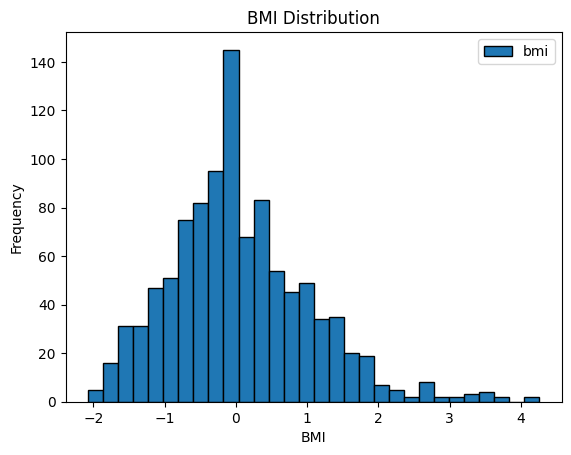

In [ ]:
X_test[['bmi']].plot(kind='hist', bins=30, edgecolor='black')
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()


In [ ]:
from tqdm import tqdm
!pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.2 MB/s eta 0:00:00


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_auc_score,roc_curve,
    precision_recall_curve,average_precision_score
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [ ]:
models = {


    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=1),


    "KNN": KNeighborsClassifier(n_neighbors=5),


    "SVC": SVC(probability=True, random_state=1,kernel='rbf',C=1,gamma=1),


    "Decision Tree": DecisionTreeClassifier(random_state=1),


    "Naive Bayes": GaussianNB(),


    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=1),


    "AdaBoost": AdaBoostClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=1),


    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=1, use_label_encoder=False),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=1),
    "LightGBM": LGBMClassifier(random_state=1)
}

  0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Confusion Matrix:
 [[976   0]
 [ 46   0]]


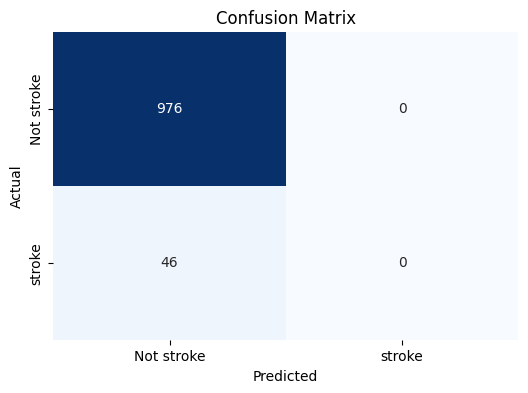


Classification Report:

              precision    recall  f1-score   support

  Not stroke       0.95      1.00      0.98       976
      stroke       0.00      0.00      0.00        46

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.91      0.95      0.93      1022

ROC-AUC: 0.8341054882394868


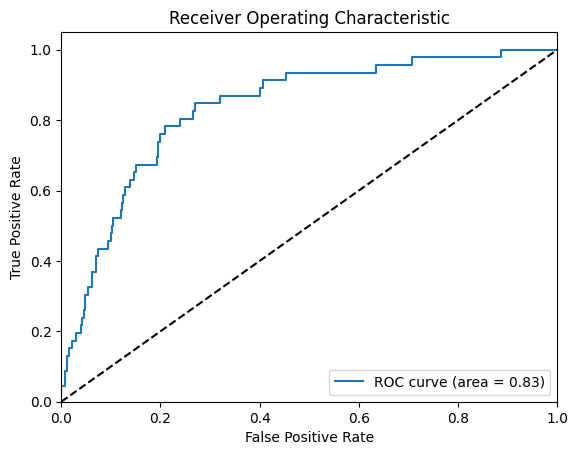

PR AUC: 0.22103136832424625


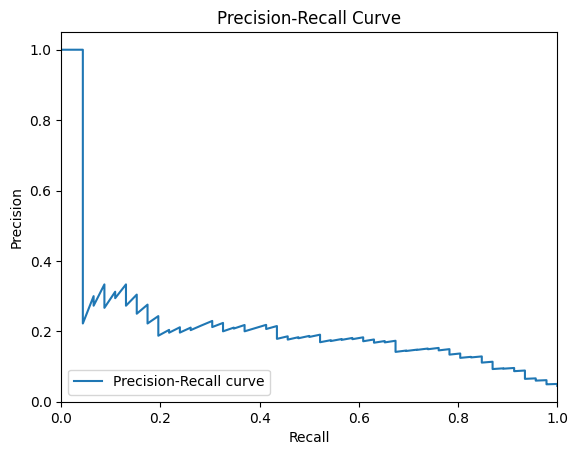

  8%|▊         | 1/13 [00:02<00:34,  2.86s/it]


Confusion Matrix:
 [[970   6]
 [ 45   1]]


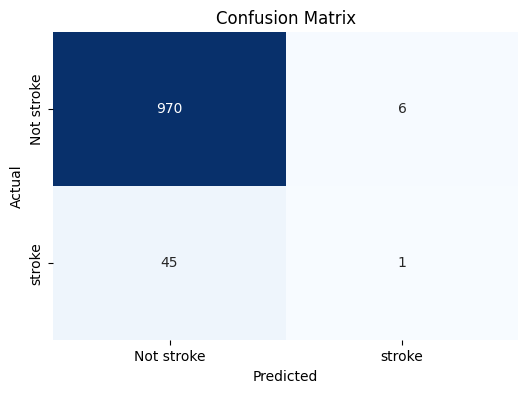


Classification Report:

              precision    recall  f1-score   support

  Not stroke       0.96      0.99      0.97       976
      stroke       0.14      0.02      0.04        46

    accuracy                           0.95      1022
   macro avg       0.55      0.51      0.51      1022
weighted avg       0.92      0.95      0.93      1022

ROC-AUC: 0.6730220955096222


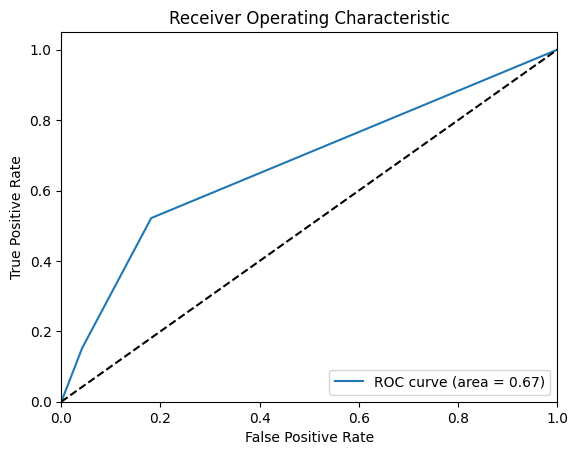

PR AUC: 0.08778093811551449


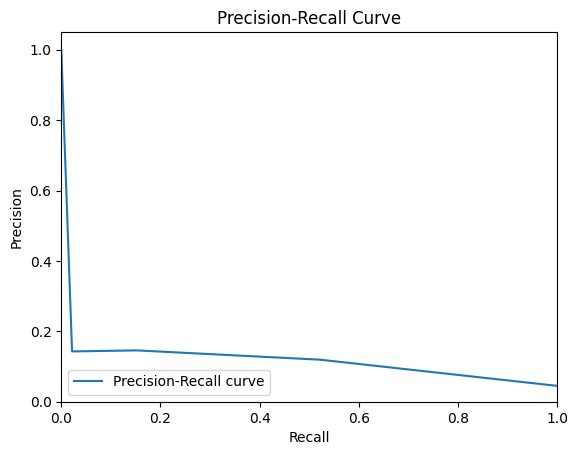

 15%|█▌        | 2/13 [00:04<00:24,  2.27s/it]


Confusion Matrix:
 [[976   0]
 [ 46   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


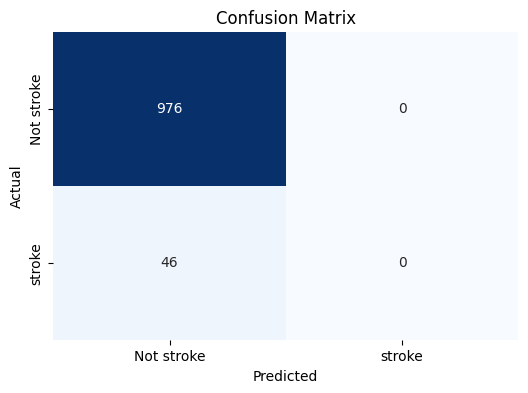


Classification Report:

              precision    recall  f1-score   support

  Not stroke       0.95      1.00      0.98       976
      stroke       0.00      0.00      0.00        46

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.91      0.95      0.93      1022

ROC-AUC: 0.7111101211689237


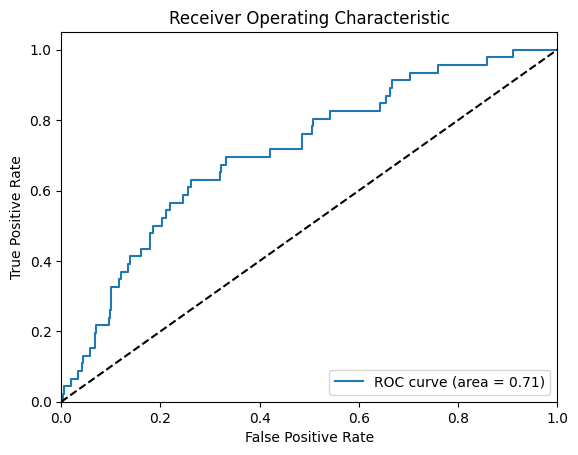

PR AUC: 0.1030992847431564


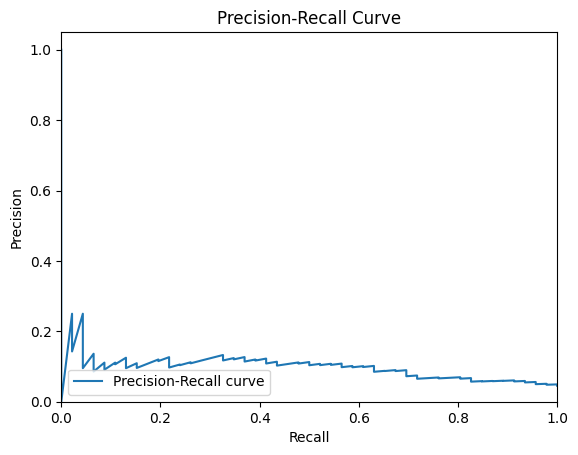

 23%|██▎       | 3/13 [00:25<01:45, 10.51s/it]


Confusion Matrix:
 [[925  51]
 [ 39   7]]


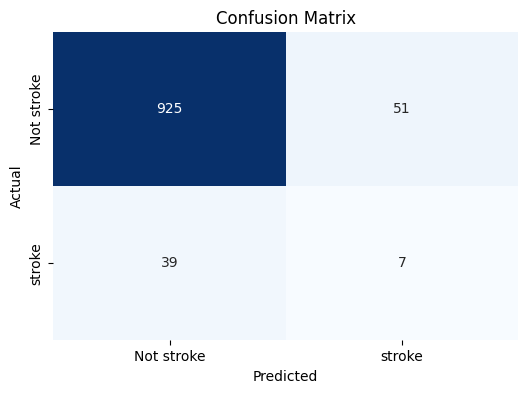


Classification Report:

              precision    recall  f1-score   support

  Not stroke       0.96      0.95      0.95       976
      stroke       0.12      0.15      0.13        46

    accuracy                           0.91      1022
   macro avg       0.54      0.55      0.54      1022
weighted avg       0.92      0.91      0.92      1022

ROC-AUC: 0.5499599073414112


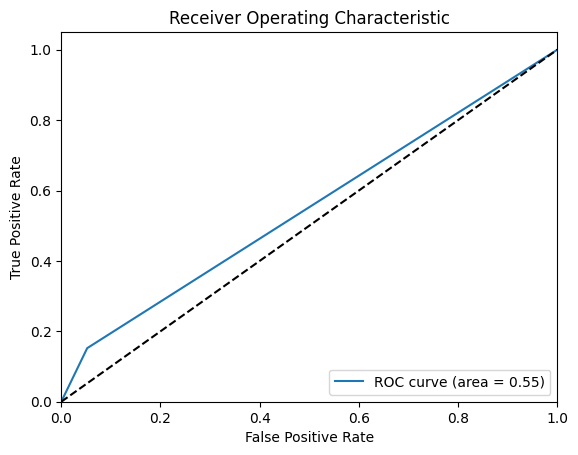

PR AUC: 0.056526286758773255


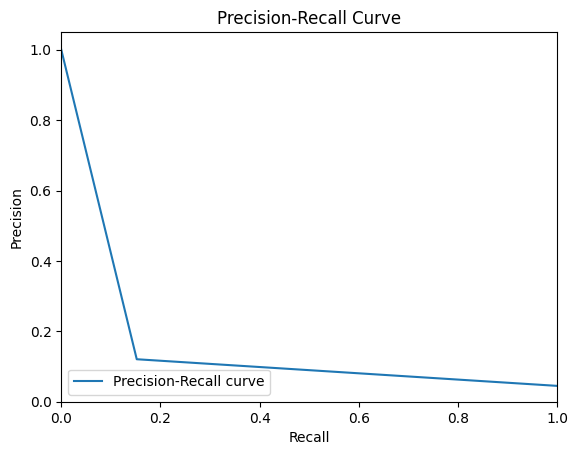

 31%|███       | 4/13 [00:25<00:59,  6.65s/it]


Confusion Matrix:
 [[336 640]
 [  1  45]]


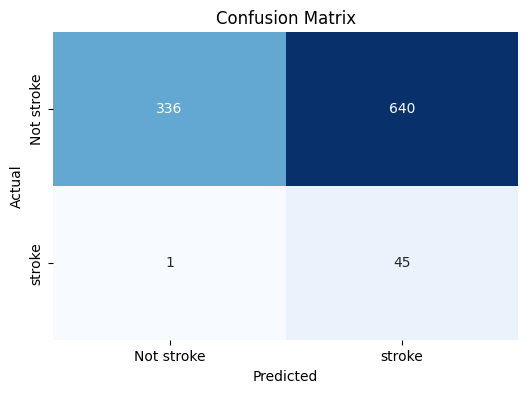


Classification Report:

              precision    recall  f1-score   support

  Not stroke       1.00      0.34      0.51       976
      stroke       0.07      0.98      0.12        46

    accuracy                           0.37      1022
   macro avg       0.53      0.66      0.32      1022
weighted avg       0.96      0.37      0.49      1022

ROC-AUC: 0.8433045260156807


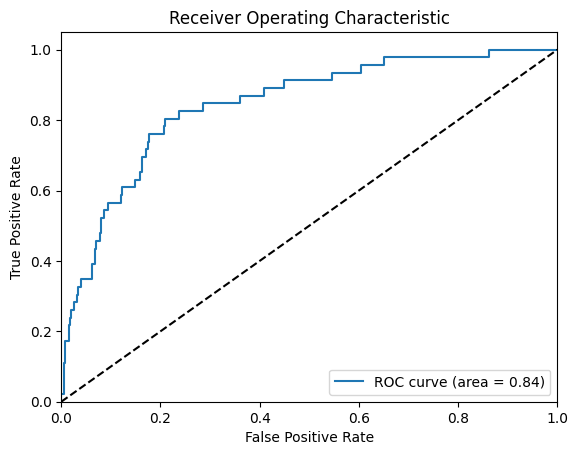

PR AUC: 0.25353448069347845


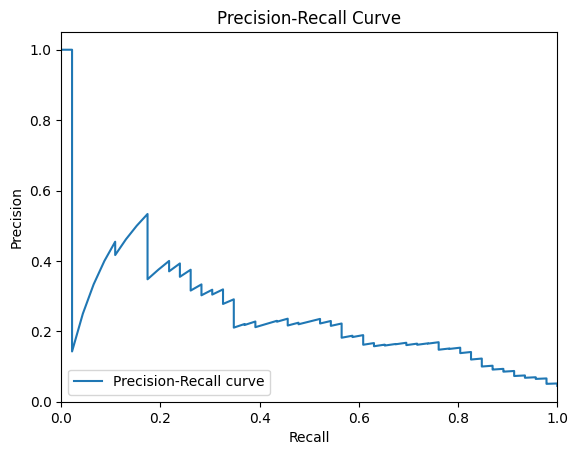

 38%|███▊      | 5/13 [00:26<00:35,  4.45s/it]


Confusion Matrix:
 [[975   1]
 [ 45   1]]


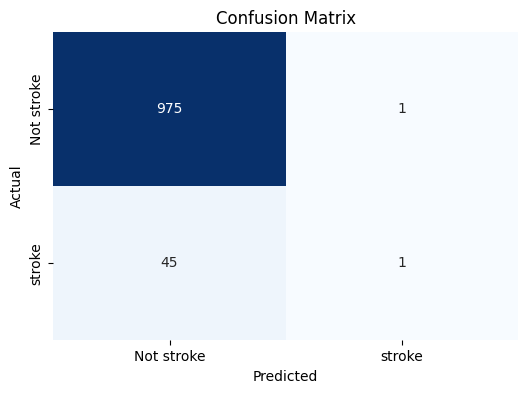


Classification Report:

              precision    recall  f1-score   support

  Not stroke       0.96      1.00      0.98       976
      stroke       0.50      0.02      0.04        46

    accuracy                           0.95      1022
   macro avg       0.73      0.51      0.51      1022
weighted avg       0.94      0.95      0.93      1022

ROC-AUC: 0.8336043300071275


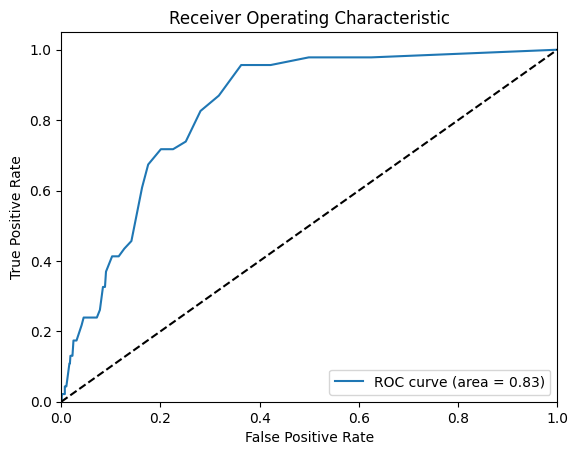

PR AUC: 0.1619452348214602


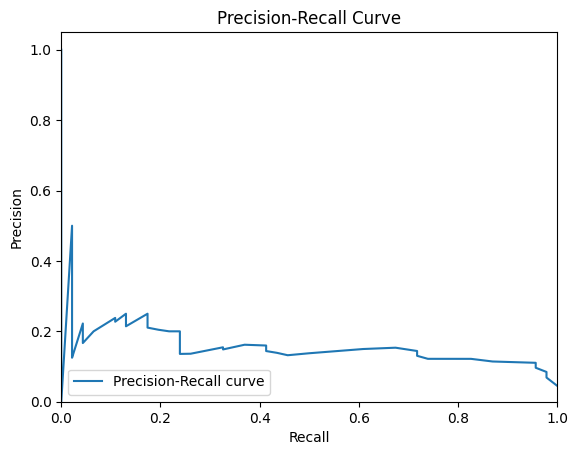

 46%|████▌     | 6/13 [00:27<00:23,  3.29s/it]


Confusion Matrix:
 [[971   5]
 [ 46   0]]


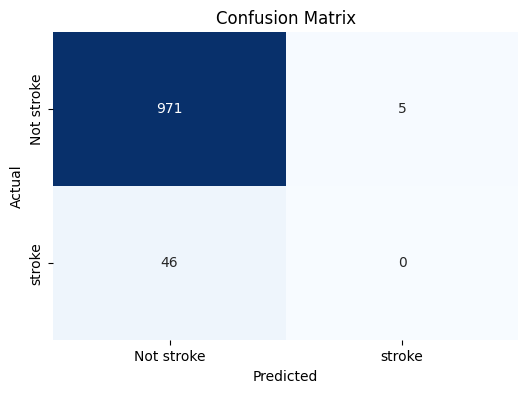


Classification Report:

              precision    recall  f1-score   support

  Not stroke       0.95      0.99      0.97       976
      stroke       0.00      0.00      0.00        46

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.91      0.95      0.93      1022

ROC-AUC: 0.7645558624376336


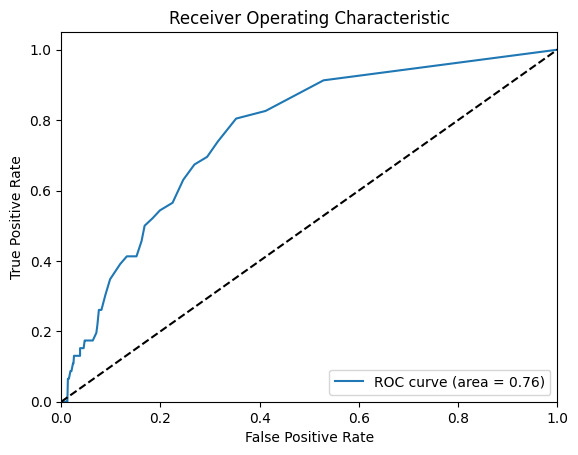

PR AUC: 0.11776052121355143


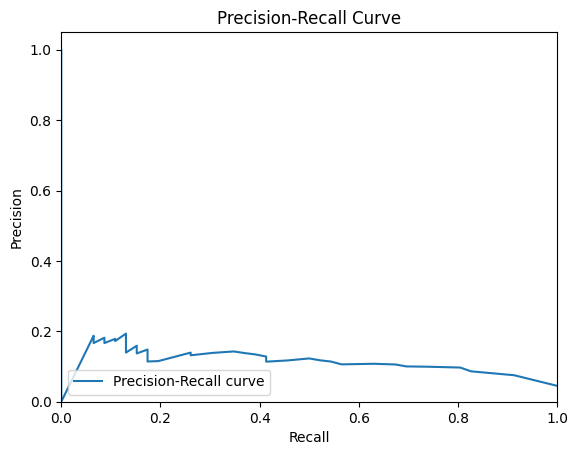

 54%|█████▍    | 7/13 [00:28<00:16,  2.69s/it]


Confusion Matrix:
 [[976   0]
 [ 46   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


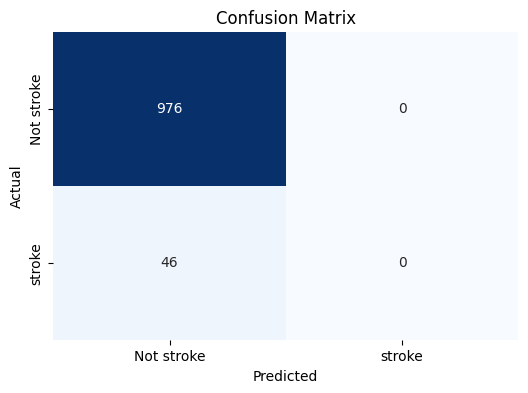


Classification Report:

              precision    recall  f1-score   support

  Not stroke       0.95      1.00      0.98       976
      stroke       0.00      0.00      0.00        46

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.91      0.95      0.93      1022

ROC-AUC: 0.8385936386315039


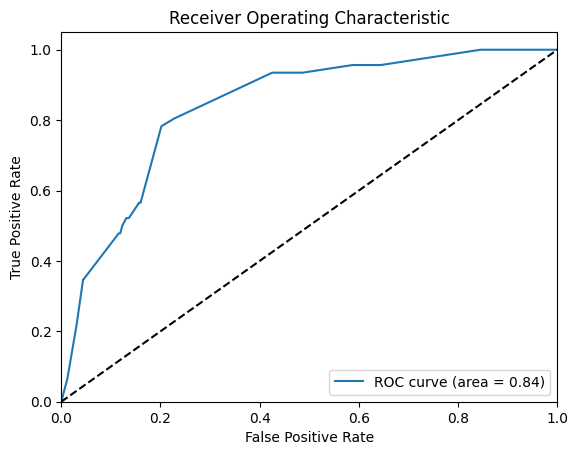

PR AUC: 0.17374591156762736


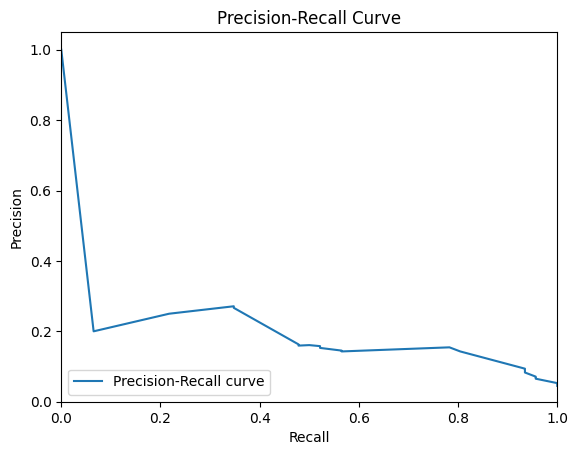

 62%|██████▏   | 8/13 [00:30<00:11,  2.24s/it]


Confusion Matrix:
 [[975   1]
 [ 46   0]]


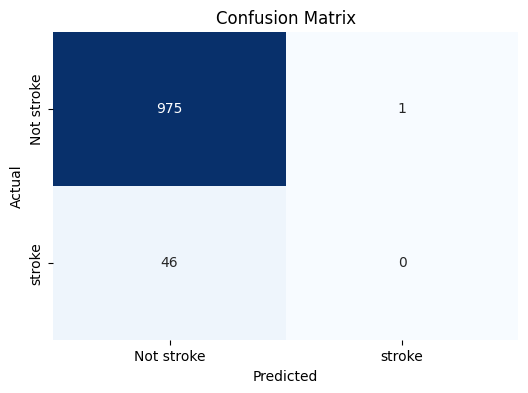


Classification Report:

              precision    recall  f1-score   support

  Not stroke       0.95      1.00      0.98       976
      stroke       0.00      0.00      0.00        46

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.91      0.95      0.93      1022

ROC-AUC: 0.8562789558089807


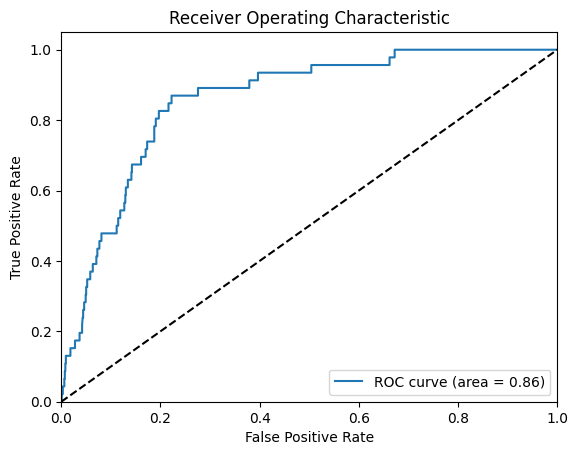

PR AUC: 0.20826092808295443


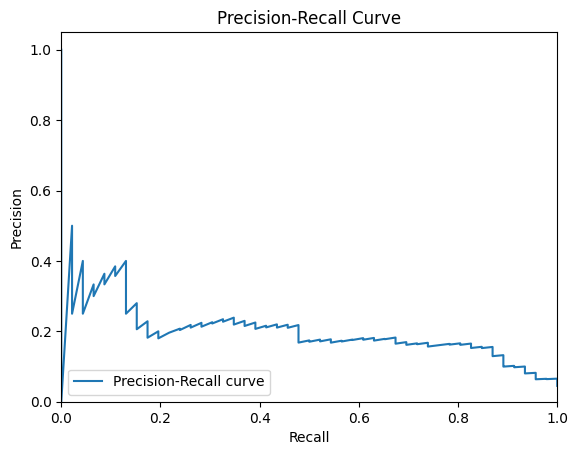

 69%|██████▉   | 9/13 [00:32<00:08,  2.23s/it]


Confusion Matrix:
 [[969   7]
 [ 44   2]]


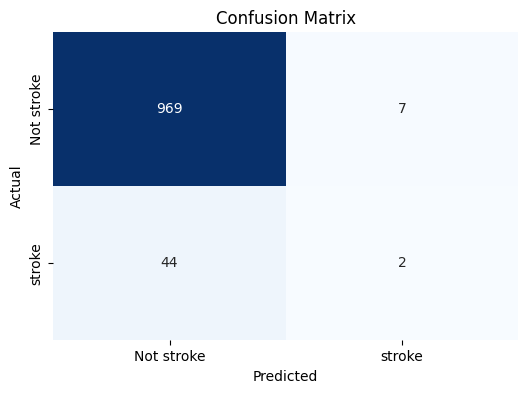


Classification Report:

              precision    recall  f1-score   support

  Not stroke       0.96      0.99      0.97       976
      stroke       0.22      0.04      0.07        46

    accuracy                           0.95      1022
   macro avg       0.59      0.52      0.52      1022
weighted avg       0.92      0.95      0.93      1022

ROC-AUC: 0.8589183891660728


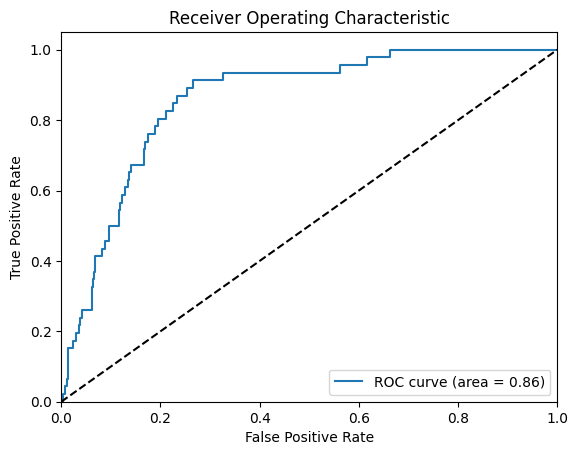

PR AUC: 0.18796435192859812


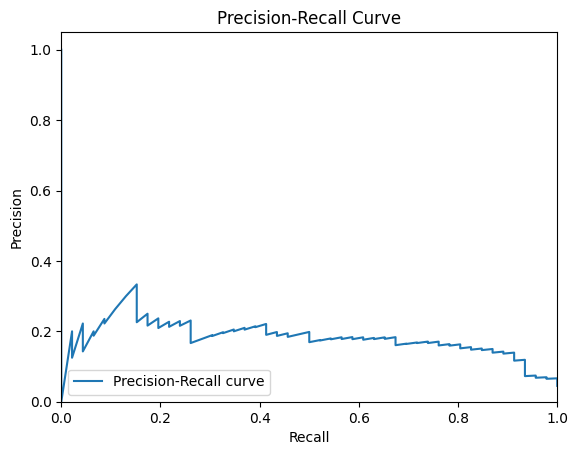

 77%|███████▋  | 10/13 [00:34<00:06,  2.16s/it]/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:06:06] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Confusion Matrix:
 [[964  12]
 [ 43   3]]


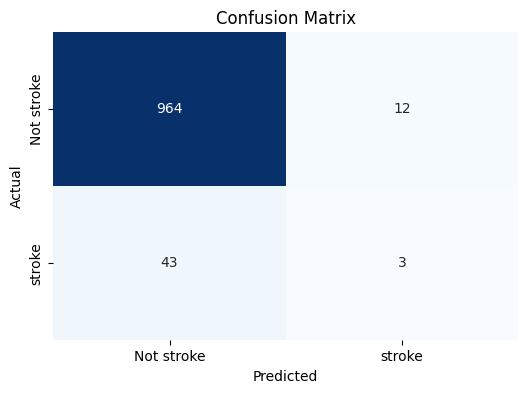


Classification Report:

              precision    recall  f1-score   support

  Not stroke       0.96      0.99      0.97       976
      stroke       0.20      0.07      0.10        46

    accuracy                           0.95      1022
   macro avg       0.58      0.53      0.54      1022
weighted avg       0.92      0.95      0.93      1022

ROC-AUC: 0.8352859942979329


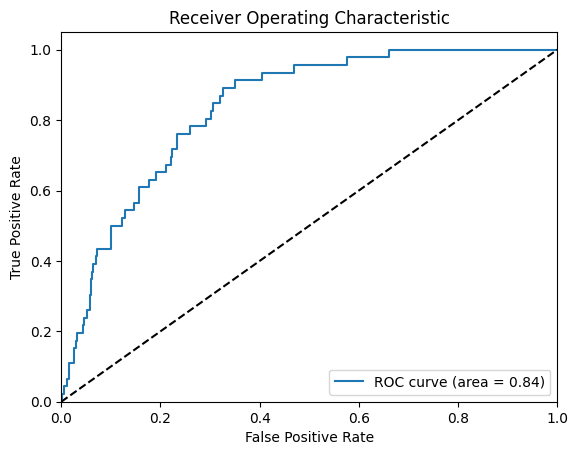

PR AUC: 0.17282929805557468


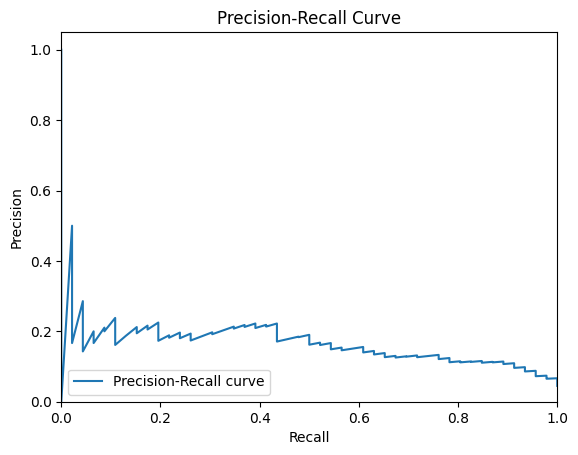

 85%|████████▍ | 11/13 [00:35<00:03,  1.83s/it]


Confusion Matrix:
 [[974   2]
 [ 41   5]]


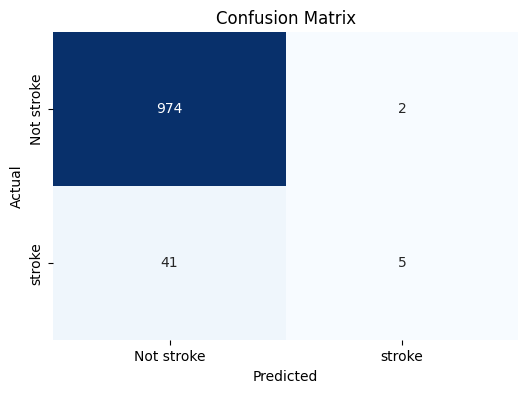


Classification Report:

              precision    recall  f1-score   support

  Not stroke       0.96      1.00      0.98       976
      stroke       0.71      0.11      0.19        46

    accuracy                           0.96      1022
   macro avg       0.84      0.55      0.58      1022
weighted avg       0.95      0.96      0.94      1022

ROC-AUC: 0.8438390947968639


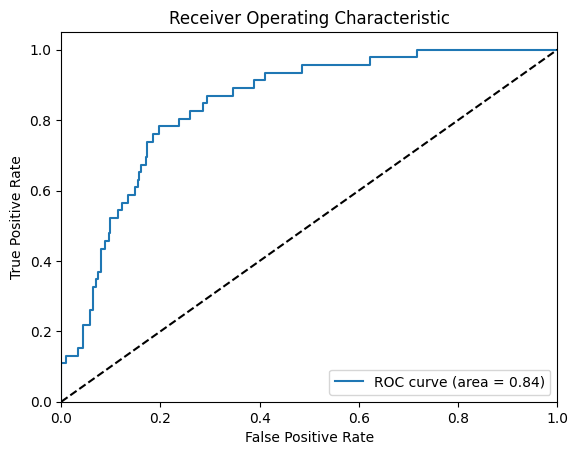

PR AUC: 0.2556160529577939


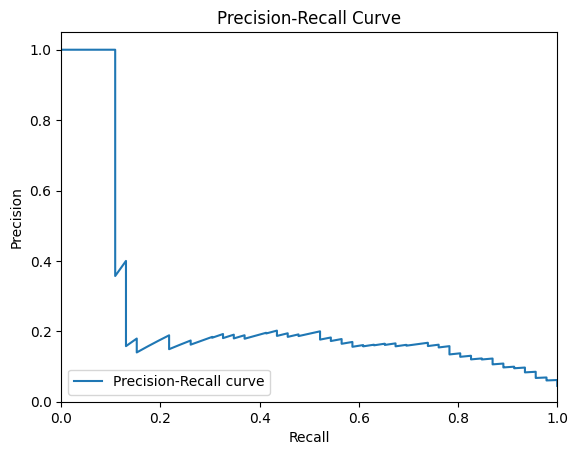

 92%|█████████▏| 12/13 [00:40<00:02,  2.96s/it]

[LightGBM] [Info] Number of positive: 203, number of negative: 3885
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000632 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 635
[LightGBM] [Info] Number of data points in the train set: 4088, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.049658 -> initscore=-2.951672
[LightGBM] [Info] Start training from score -2.951672

Confusion Matrix:
 [[970   6]
 [ 45   1]]


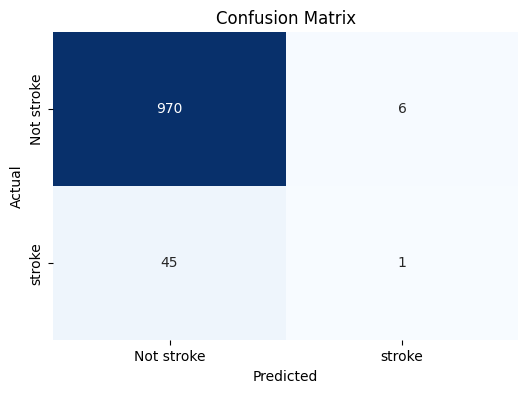


Classification Report:

              precision    recall  f1-score   support

  Not stroke       0.96      0.99      0.97       976
      stroke       0.14      0.02      0.04        46

    accuracy                           0.95      1022
   macro avg       0.55      0.51      0.51      1022
weighted avg       0.92      0.95      0.93      1022

ROC-AUC: 0.8457546329294369


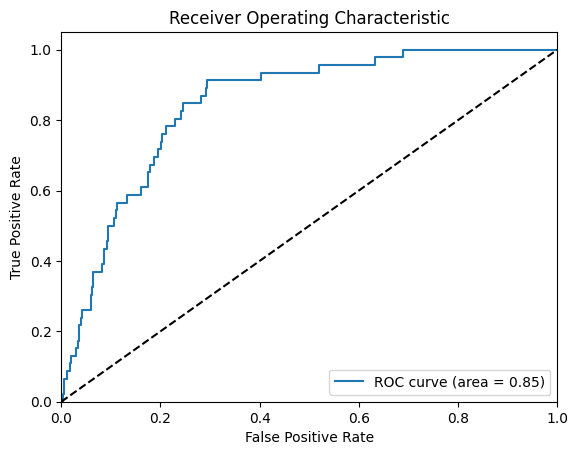

PR AUC: 0.1777352801038446


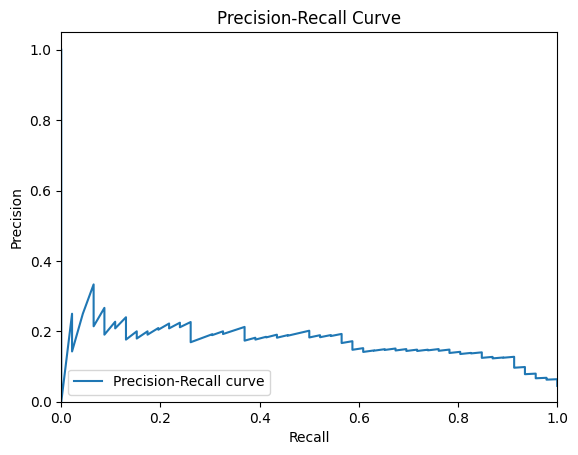

100%|██████████| 13/13 [00:42<00:00,  3.24s/it]


In [ ]:
results = {}
import seaborn as sns
for name, model in tqdm(models.items()):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)

    results[name] = {
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train Precision": precision_score(y_train, train_pred),
        "Test Precision": precision_score(y_test, test_pred),
        "Train Recall": recall_score(y_train, train_pred),
        "Test Recall": recall_score(y_test, test_pred),
        "Train F1 Score": f1_score(y_train, train_pred),
        "Test F1 Score": f1_score(y_test, test_pred),
        "Train Balanced Accuracy": balanced_accuracy_score(y_train, train_pred),
        "Test Balanced Accuracy": balanced_accuracy_score(y_test, test_pred)

    }

    cm = confusion_matrix(y_test, test_pred)
    print("\nConfusion Matrix:\n", cm)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm,annot=True,fmt="d",cmap='Blues',cbar=False,
                xticklabels=['Not stroke','stroke']
                ,yticklabels=['Not stroke','stroke'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

    # Full classification report
    print("\nClassification Report:\n")
    print(classification_report(y_test, test_pred,target_names=['Not stroke','stroke'],zero_division=0))

    y_pred_prob = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    print("ROC-AUC:", roc_auc)

    # ROC curve
    fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_prob)
    plt.figure()
    plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

    pr_auc = average_precision_score(y_test, y_pred_prob)
    print("PR AUC:", pr_auc)

    precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)
    plt.figure()
    plt.plot(recall_vals, precision_vals, label='Precision-Recall curve')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="Test F1 Score", ascending=False)
results_df

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1 Score,Test F1 Score,Train Balanced Accuracy,Test Balanced Accuracy
CatBoost,0.974070,0.957926,1.000000,0.714286,0.477833,0.108696,0.646667,0.188679,0.738916,0.553323
Decision Tree,1.000000,0.911937,1.000000,0.120690,1.000000,0.152174,1.000000,0.134615,1.000000,0.549960
Naive Bayes,0.397260,0.372798,0.075479,0.065693,0.990148,0.978261,0.140265,0.123119,0.678214,0.661262
XGBoost,0.996820,0.946184,1.000000,0.200000,0.935961,0.065217,0.966921,0.098361,0.967980,0.526461
Hist Gradient Boosting,0.988992,0.950098,0.987654,0.222222,0.788177,0.043478,0.876712,0.072727,0.893831,0.518153
Random Forest,1.000000,0.954990,1.000000,0.500000,1.000000,0.021739,1.000000,0.041667,1.000000,0.510357
LightGBM,0.990705,0.950098,1.000000,0.142857,0.812808,0.021739,0.896739,0.037736,0.906404,0.507796
KNN,0.951810,0.950098,0.607143,0.142857,0.083744,0.021739,0.147186,0.037736,0.540456,0.507796
Logistic Regression,0.950342,0.954990,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.500000
SVC,0.999755,0.954990,1.000000,0.000000,0.995074,0.000000,0.997531,0.000000,0.997537,0.500000
